In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, Input, Concatenate
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

tf.config.optimizer.set_experimental_options({
    "disable_meta_optimizer": True,
    "tfg_optimizer": False
})

# 1. Генерація даних
np.random.seed(42)
X = np.random.uniform(-3, 7, (1000, 2))
# Цільова функція: y = x0^3 + x1^2 * sin(x0)
y = X[:, 0]**3 + X[:, 1]**2 * np.sin(X[:, 0])

X_train, X_test = X[:800], X[800:]
y_train, y_test = y[:800], y[800:]

# 2. Feed-Forward (Sequential)
ff_model1 = Sequential([
    Input(shape=(2,)), 
    Dense(10, activation='relu'), 
    Dense(1)
], name="Feed_Forward_10")

ff_model2 = Sequential([
    Input(shape=(2,)), 
    Dense(20, activation='relu'), 
    Dense(1)
], name="Feed_Forward_20")

# 3. Cascade Forward 
inputs_c1 = Input(shape=(2,))
h1_c1 = Dense(20, activation='relu')(inputs_c1)
concat_c1 = Concatenate()([inputs_c1, h1_c1])
output_c1 = Dense(1)(concat_c1)
cascade1 = Model(inputs_c1, output_c1, name="Cascade_20")

# Cascade 2
inputs_c2 = Input(shape=(2,))
h1_c2 = Dense(10, activation='relu')(inputs_c2)
c1_c2 = Concatenate()([inputs_c2, h1_c2])
h2_c2 = Dense(10, activation='relu')(c1_c2)
c2_c2 = Concatenate()([inputs_c2, h1_c2, h2_c2])
output_c2 = Dense(1)(c2_c2)
cascade2 = Model(inputs_c2, output_c2, name="Cascade_10x2")

# 4. Elman Networks (SimpleRNN)
X_train_rnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_rnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

elman1 = Sequential([
    Input(shape=(2, 1)), 
    SimpleRNN(15, activation='relu'), 
    Dense(1)
], name="Elman_15")

elman2 = Sequential([
    Input(shape=(2, 1)),
    SimpleRNN(5, activation='relu', return_sequences=True),
    SimpleRNN(5, activation='relu', return_sequences=True),
    SimpleRNN(5, activation='relu'),
    Dense(1)
], name="Elman_5x3")

results = {}

# Group models by data
models_2d = [ff_model1, ff_model2, cascade1, cascade2]
models_3d = [elman1, elman2]

EPOCHS = 100
BATCH_SIZE = 32

def train_and_evaluate(models_list, X_tr, X_te, y_tr, y_te):
    tf.keras.backend.clear_session()
    for model in models_list:
        print(f"Навчання моделі: {model.name}...")
        
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        
        history = model.fit(
            X_tr, y_tr, 
            epochs=EPOCHS, 
            batch_size=BATCH_SIZE, 
            validation_split=0.2,
            verbose=0
        )
        
        y_pred = model.predict(X_te, verbose=0).flatten()
        
        mse, mae = model.evaluate(X_te, y_te, verbose=0)
        r2 = r2_score(y_te, y_pred)
        
        results[model.name] = {
            'MSE': mse,
            'MAE': mae,
            'R2 Score': r2,
            'History_Loss': history.history['loss'],
            'History_Val_Loss': history.history['val_loss'],
            'Predictions': y_pred
        }
        print(f"R2: {r2:.4f}\n")

train_and_evaluate(models_2d, X_train, X_test, y_train, y_test)
train_and_evaluate(models_3d, X_train_rnn, X_test_rnn, y_train, y_test)

results_df = pd.DataFrame(results).T
print("\n Таблиця результатів:")
print(results_df[['MSE', 'MAE', 'R2 Score']].sort_values(by='R2 Score', ascending=False))


Навчання моделі: Feed_Forward_10...
R2: 0.7178

Навчання моделі: Feed_Forward_20...
R2: 0.7660

Навчання моделі: Cascade_20...
R2: 0.7444

Навчання моделі: Cascade_10x2...
R2: 0.8600

Навчання моделі: Elman_15...
R2: 0.8787

Навчання моделі: Elman_5x3...
R2: 0.9692


 Таблиця результатів:
                         MSE        MAE  R2 Score
Elman_5x3         294.921844   12.07714   0.96923
Elman_15         1162.207397  24.802235  0.878744
Cascade_10x2     1342.053589  25.357962   0.85998
Feed_Forward_20  2242.870117  34.058365  0.765996
Cascade_20       2449.951172  35.673084  0.744391
Feed_Forward_10  2705.186035  35.843658  0.717761


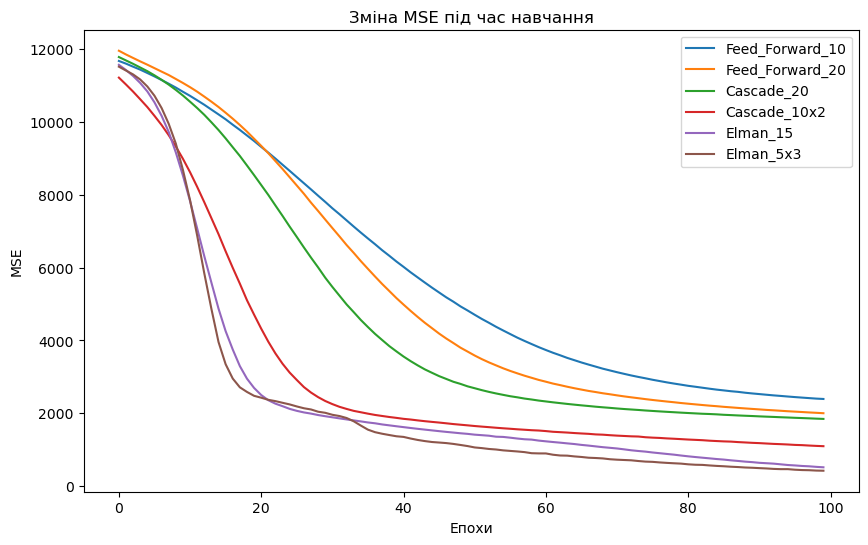

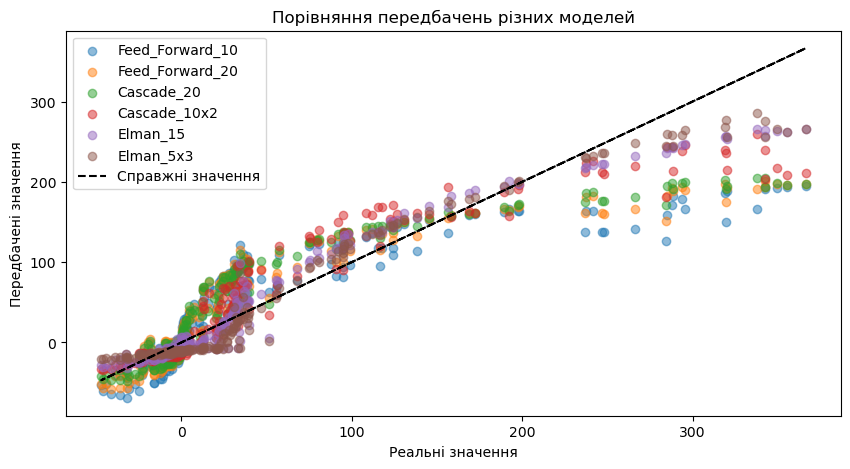

In [3]:
plt.figure(figsize=(10, 6))
for name, data in results.items():
    plt.plot(data['History_Loss'], label=name)

plt.title("Зміна MSE під час навчання")
plt.xlabel("Епохи")
plt.ylabel("MSE")
plt.legend()
plt.show()

# Графік 2: Порівняння передбачень різних моделей
plt.figure(figsize=(10, 5))
for name, data in results.items():
    plt.scatter(y_test, data['Predictions'], label=name, alpha=0.5)

plt.plot(y_test, y_test, 'k--', label="Справжні значення")
plt.xlabel("Реальні значення")
plt.ylabel("Передбачені значення")
plt.legend()
plt.title("Порівняння передбачень різних моделей")
plt.show()